In [4]:
# Project: Short term PFKFB3 mouse project
# code: Munich_biobank_glyco_1
# Aim: To parse out single cell glycolytic fetures and associated inflammatory features from the 
#      Munich vascular biobank single cell dataset
# Author: Monojit
# Date: 02/05/2026

In [5]:
#Loading the libraries

import numpy as np
import pandas as pd
import scanpy as sc
import sparse as sp
import gseapy as gp
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [6]:
# Loading Munich Biobank dataset
from pathlib import Path

dataset_path = Path("GRCh38-p14-Gencode_v44_with_intron_final_data.h5ad")
if not dataset_path.is_file():
    dataset_path = Path("..") / dataset_path
if not dataset_path.is_file():
    raise FileNotFoundError(
        f"Could not find {dataset_path.name} from working directory {Path.cwd()}"
    )

munich = sc.read_h5ad(dataset_path)

# converting HGNC gene name as the rownames/variable names of the dataset
munich.var_names = munich.var_names.astype(str)
munich.var_names_make_unique()
munich.var["HGNC_NAME"] = munich.var["HGNC_NAME"].astype(str)
munich.var_names = munich.var["HGNC_NAME"].astype(str)
munich.var_names = munich.var_names.astype(str)
munich.var_names_make_unique()

# Preparing for the ssgsea by making the dataset as matrix
expr = pd.DataFrame(
    munich.X.T,
    index=munich.var_names,
    columns=munich.obs_names
)

In [7]:

# Running the ssGSEA
ss = gp.ssgsea(
    data=expr,
    gene_sets='MSigDB_Hallmark_2020',
    sample_norm_method='rank',
    permutation_num=0,
    processes=40,
    no_plot=True
)

scores = ss.res2d
score_matrix = scores.pivot(
    index='Name',
    columns='Term',
    values='NES'
)
score_matrix = score_matrix.loc[munich.obs_names]


/tmp/ipykernel_2416562/2997160599.py:2: DeprecationWarning: processes is deprecated; use threads
  ss = gp.ssgsea(


In [8]:
# Parsing out the ssgsea scores and pathways into the AnnData object
munich.obsm["ssgsea"] = score_matrix.values
munich.uns["ssgsea_pathways"] = score_matrix.columns.tolist()


In [9]:
# Preselecting several pathways of interest for downstream analysis
pathways=["Glycolysis", "Fatty Acid Metabolism", "Inflammatory Response", "TNF-alpha Signaling via NF-kB", "IL-6/JAK/STAT3 Signaling","Interferon Gamma Response"]

for pathway in pathways:
    idx = munich.uns["ssgsea_pathways"].index(pathway)
    score_nes_name = (
        pathway.replace(" ", "_")
        + "_NES")
    print(score_nes_name)
    munich.obs[score_nes_name] = munich.obsm["ssgsea"][:, idx]

Glycolysis_NES
Fatty_Acid_Metabolism_NES
Inflammatory_Response_NES
TNF-alpha_Signaling_via_NF-kB_NES
IL-6/JAK/STAT3_Signaling_NES
Interferon_Gamma_Response_NES


In [10]:
# Subsetting the dataset to only include plaque cells for downstream analysis
munich_plaque=munich[munich.obs["condition"]=="Plaque"]


/home/monojit/miniconda3/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


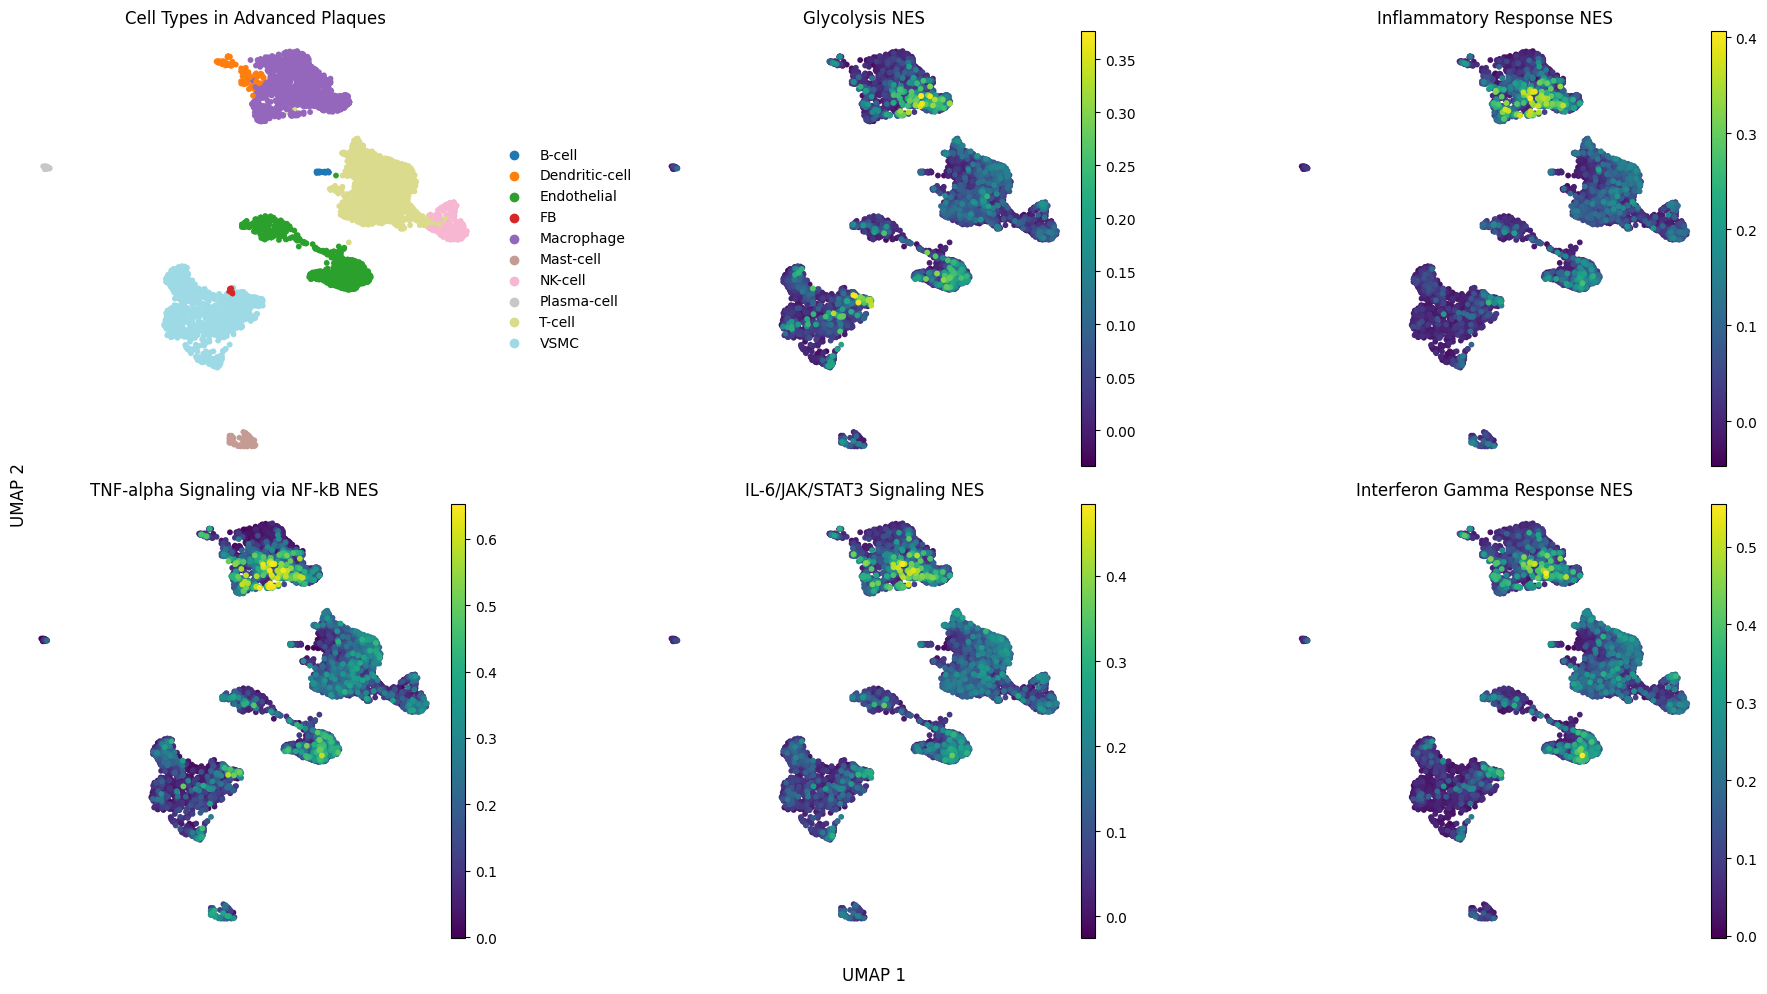

In [11]:
# Visualization of the selected features in the plaque cells
# Figure 1A

features = [
    "final_high_level_celltype",
    "Glycolysis_NES",
    "Inflammatory_Response_NES",
    "TNF-alpha_Signaling_via_NF-kB_NES",
    "IL-6/JAK/STAT3_Signaling_NES",
    "Interferon_Gamma_Response_NES"
]

titles = [
    "Cell Types in Advanced Plaques",
    "Glycolysis NES",
    "Inflammatory Response NES",
    "TNF-alpha Signaling via NF-kB NES",
    "IL-6/JAK/STAT3 Signaling NES",
    "Interferon Gamma Response NES"
]
# 1 rows × 3 columns layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sc.pl.umap(
        munich_plaque,
        color=feature,
        ax=axes[i],
        show=False,
        frameon=False,
        size=70,
        cmap="viridis",
        palette="tab20",
        legend_loc="right margin",
        title=titles[i]
    )

# remove empty axes if any (safety)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

fig.supxlabel("UMAP 1")
fig.supylabel("UMAP 2")

plt.tight_layout()

#plt.savefig(
#   "figures/ssgsea/glyco_featureplot_plaque_atlas_multipanel_updated.pdf",
#    dpi=600,
#    facecolor="white",
#    bbox_inches="tight"
#)


In [12]:
plt.close()

In [13]:
munich_ec=munich[(munich.obs["final_high_level_celltype"]=="Endothelial") & (munich.obs["condition"]=="Plaque")]

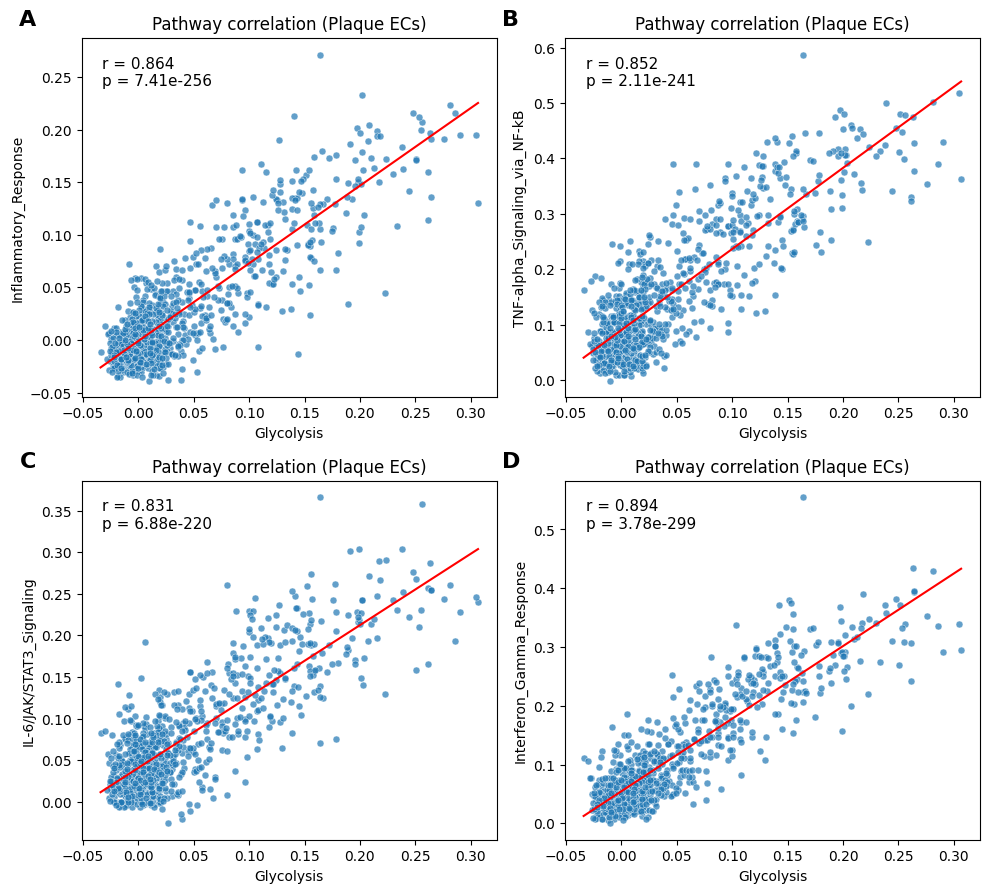

In [ ]:
# Checking the association of the selected features within the endothelial cells in the plaque settings
# Supplemental Figure 
pathway_pairs = [
    ("Glycolysis_NES", "Inflammatory_Response_NES"),
    ("Glycolysis_NES", "TNF-alpha_Signaling_via_NF-kB_NES"),
    ("Glycolysis_NES", "IL-6/JAK/STAT3_Signaling_NES"),
    ("Glycolysis_NES", "Interferon_Gamma_Response_NES")
]

panel_labels = ["A", "B", "C", "D"]

# --------------------------------------------------
# Create 2 × 2 figure
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 9)
)

axes = axes.flatten()

for ax, (x_col, y_col), label in zip(axes, pathway_pairs, panel_labels):

    # Prepare data
    df = pd.DataFrame({
        "x": pd.to_numeric(munich_ec.obs[x_col], errors="coerce"),
        "y": pd.to_numeric(munich_ec.obs[y_col], errors="coerce")
    }).dropna()

    # Pearson correlation
    pearson_r, pearson_p = pearsonr(
        df["x"].to_numpy(dtype=np.float64),
        df["y"].to_numpy(dtype=np.float64)
    )

    # Scatter plot
    sns.scatterplot(
        data=df,
        x="x",
        y="y",
        s=25,
        alpha=0.7,
        ax=ax
    )

    # Regression line
    sns.regplot(
        data=df,
        x="x",
        y="y",
        scatter=False,
        ci=None,
        line_kws={"linewidth": 1.5},
        color="red",
        ax=ax
    )

    # Panel label
    ax.text(
        -0.15, 1.08,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top"
    )

    # Labels
    ax.set_xlabel(x_col.replace("_NES", ""))
    ax.set_ylabel(y_col.replace("_NES", ""))

    # Correlation statistics
    ax.text(
        0.05, 0.95,
        f"r = {pearson_r:.3f}\np = {pearson_p:.2e}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11
    )

    ax.set_title("Pathway correlation (Plaque ECs)")

plt.tight_layout()

plt.savefig(
    "pathway_correlation_plaque_all.pdf",
    bbox_inches="tight",
    dpi=1200,
    facecolor="white"
)

plt.show()

In [15]:
plt.close()

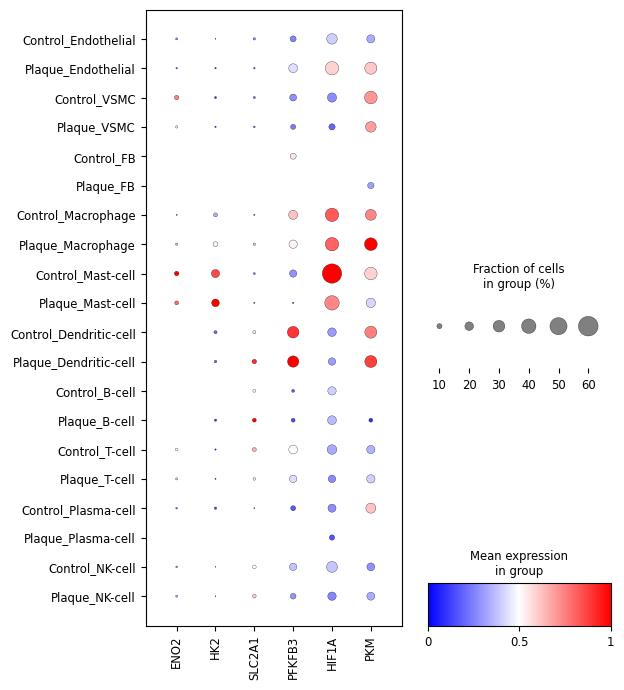

In [22]:
# Reproduction of the Figure 1B - glycolytic gene in dotplot in all cells in palque and control condition (munich biobank dataset)

munich.obs["exp_group"]= (munich.obs["condition"].astype(str) + "_" + munich.obs["final_high_level_celltype"].astype(str))
order=["Control_Endothelial", "Plaque_Endothelial", "Control_VSMC", "Plaque_VSMC", "Control_FB", "Plaque_FB","Control_Macrophage", "Plaque_Macrophage","Control_Mast-cell", "Plaque_Mast-cell","Control_Dendritic-cell", "Plaque_Dendritic-cell", "Control_B-cell", "Plaque_B-cell", "Control_T-cell", "Plaque_T-cell","Control_Plasma-cell", "Plaque_Plasma-cell","Control_NK-cell", "Plaque_NK-cell"]

munich.obs["exp_group"] = pd.Categorical(
     munich.obs["exp_group"],
     categories=order,
     ordered=True
 )

# glycolytic genes of interest
genes=["ENO2", "HK2", "SLC2A1", "PFKFB3", "HIF1A", "PKM"]

# Custom colormap for the dotplot
custom_cmap = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["blue", "white", "red"]
)

dp_celltype = sc.pl.dotplot(
    munich,
    var_names=genes,
    groupby="exp_group",
    layer="acosh",
    use_raw=False,
    cmap=custom_cmap,
    standard_scale="var",
    figsize=(6, 8),
    return_fig=True
)

dp_celltype.legend(width=2.5)
dp_celltype.make_figure()

# Find the colorbar axis and set breaks
colorbar_ax = dp_celltype.ax_dict["color_legend_ax"]
colorbar_ax.set_xticks([0, 0.5, 1])
colorbar_ax.set_xticklabels(["0", "0.5", "1"])

fig2 = dp_celltype.get_axes()["mainplot_ax"].get_figure()
#fig2.savefig("figures/dotplot_munich_con_pla1_subtype_dotplot.pdf", bbox_inches='tight', dpi=600)


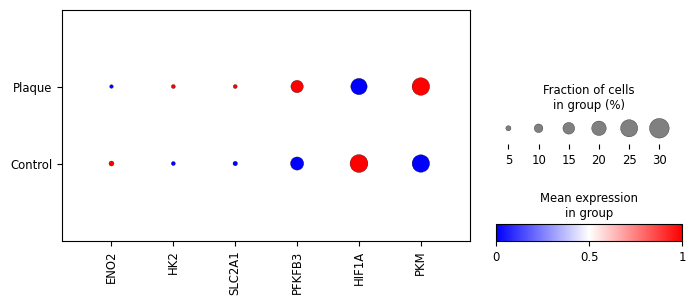

In [23]:
# Reproduction of the Figure 1C - glycolytic gene in dotplot in endothelial cells in palque and control condition (munich biobank dataset)
# glycolytic genes of interest
genes=["ENO2", "HK2", "SLC2A1", "PFKFB3", "HIF1A", "PKM"]

# Custom colormap for the dotplot
custom_cmap = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["blue", "white", "red"]
)

dp_celltype = sc.pl.dotplot(
    munich,
    var_names=genes,
    groupby="condition",
    layer="acosh",
    use_raw=False,
    cmap=custom_cmap,
    standard_scale="var",
    figsize=(8, 3),
    return_fig=True
)

dp_celltype.legend(width=2.5)
dp_celltype.make_figure()

# Find the colorbar axis and set breaks
colorbar_ax = dp_celltype.ax_dict["color_legend_ax"]
colorbar_ax.set_xticks([0, 0.5, 1])
colorbar_ax.set_xticklabels(["0", "0.5", "1"])

fig2 = dp_celltype.get_axes()["mainplot_ax"].get_figure()
#fig2.savefig("figures/dotplot_munich_con_pla1_subtype_dotplot.pdf", bbox_inches='tight', dpi=600)
